# Знакомство с Pandas на примере разведочного анализа данных




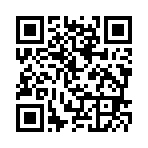

<img src="http://sharpsightlabs.com/wp-content/uploads/2016/05/1_data-analysis-for-ML_how-we-use-dataAnalysis_2016-05-16.png" />

In [ ]:
# импортируем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')

import warnings
warnings.filterwarnings("ignore")

Сегодня мы будем анализировать данные о домах в Калифорнии с [Kaggle](https://www.kaggle.com/c/zillow-prize-1/overview/competition-overview). Каждая строка в нашей таблице содержит информацию о некоторых апартаментах. Глобальная задача - предсказать цену на дом. Но сегодня мы будем анализировать сами данные средствами Python.

Загружаем данные с помощью библиотеки `pandas`. Pandas - это одна из наиболее популрных библиотек дл работы с данными. В ней реализованы многие методы, которые позволяют сильно упростить работу по анализу данных.

Данные хранятся в формате `csv` - это почти excel-таблица, но не совсем ;)

**CSV** (от англ. Comma-Separated Values — значения, разделённые запятыми) — текстовый формат, предназначенный для представления табличных данных. Строка таблицы соответствует строке текста, которая содержит одно или несколько полей, разделенных запятыми.

In [ ]:
file_id = "1ck7EiKlPTwKnXUHBMDtn6zfUB58PqwHG"
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id={file_id}' -O train_home_price.csv

--2026-03-19 15:14:36--  https://docs.google.com/uc?export=download&id=1ck7EiKlPTwKnXUHBMDtn6zfUB58PqwHG
Resolving docs.google.com (docs.google.com)... 142.251.121.100, 142.251.121.113, 142.251.121.102, ...
Connecting to docs.google.com (docs.google.com)|142.251.121.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1ck7EiKlPTwKnXUHBMDtn6zfUB58PqwHG&export=download [following]
--2026-03-19 15:14:36--  https://drive.usercontent.google.com/download?id=1ck7EiKlPTwKnXUHBMDtn6zfUB58PqwHG&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.142.132, 2607:f8b0:4023:80d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.142.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 460676 (450K) [application/octet-stream]
Saving to: ‘train_home_price.csv’

train_home_price.cs 100%[===================>] 449.88K  --

In [ ]:
# подгружаем данные
data = pd.read_csv('train_home_price.csv', index_col=0)
data.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


Посмотрим названия признаков.

In [ ]:
sorted(data.columns.tolist())

['1stFlrSF',
 '2ndFlrSF',
 '3SsnPorch',
 'Alley',
 'BedroomAbvGr',
 'BldgType',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtFinType1',
 'BsmtFinType2',
 'BsmtFullBath',
 'BsmtHalfBath',
 'BsmtQual',
 'BsmtUnfSF',
 'CentralAir',
 'Condition1',
 'Condition2',
 'Electrical',
 'EnclosedPorch',
 'ExterCond',
 'ExterQual',
 'Exterior1st',
 'Exterior2nd',
 'Fence',
 'FireplaceQu',
 'Fireplaces',
 'Foundation',
 'FullBath',
 'Functional',
 'GarageArea',
 'GarageCars',
 'GarageCond',
 'GarageFinish',
 'GarageQual',
 'GarageType',
 'GarageYrBlt',
 'GrLivArea',
 'HalfBath',
 'Heating',
 'HeatingQC',
 'HouseStyle',
 'KitchenAbvGr',
 'KitchenQual',
 'LandContour',
 'LandSlope',
 'LotArea',
 'LotConfig',
 'LotFrontage',
 'LotShape',
 'LowQualFinSF',
 'MSSubClass',
 'MSZoning',
 'MasVnrArea',
 'MasVnrType',
 'MiscFeature',
 'MiscVal',
 'MoSold',
 'Neighborhood',
 'OpenPorchSF',
 'OverallCond',
 'OverallQual',
 'PavedDrive',
 'PoolArea',
 'PoolQC',
 'RoofMatl',
 'RoofStyle',
 'Sa

Как мы видим, их довольно много. Сколько?

In [ ]:
data.shape

(1460, 80)

**Вот полное описание этих признаков:**
    
* SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.
* MSSubClass: The building class
* MSZoning: The general zoning classification
* LotFrontage: Linear feet of street connected to property
* LotArea: Lot size in square feet
* Street: Type of road access
* Alley: Type of alley access
* LotShape: General shape of property
* LandContour: Flatness of the property
* Utilities: Type of utilities available
* LotConfig: Lot configuration
* LandSlope: Slope of property
* Neighborhood: Physical locations within Ames city limits
* Condition1: Proximity to main road or railroad
* Condition2: Proximity to main road or railroad (if a second is present)
* BldgType: Type of dwelling
* HouseStyle: Style of dwelling
* OverallQual: Overall material and finish quality
* OverallCond: Overall condition rating
* YearBuilt: Original construction date
* YearRemodAdd: Remodel date
* RoofStyle: Type of roof
* RoofMatl: Roof material
* Exterior1st: Exterior covering on house
* Exterior2nd: Exterior covering on house (if more than one material)
* MasVnrType: Masonry veneer type
* MasVnrArea: Masonry veneer area in square feet
* ExterQual: Exterior material quality
* ExterCond: Present condition of the material on the exterior
* Foundation: Type of foundation
* BsmtQual: Height of the basement
* BsmtCond: General condition of the basement
* BsmtExposure: Walkout or garden level basement walls
* BsmtFinType1: Quality of basement finished area
* BsmtFinSF1: Type 1 finished square feet
* BsmtFinType2: Quality of second finished area (if present)
* BsmtFinSF2: Type 2 finished square feet
* BsmtUnfSF: Unfinished square feet of basement area
* TotalBsmtSF: Total square feet of basement area
* Heating: Type of heating
* HeatingQC: Heating quality and condition
* CentralAir: Central air conditioning
* Electrical: Electrical system
* 1stFlrSF: First Floor square feet
* 2ndFlrSF: Second floor square feet
* LowQualFinSF: Low quality finished square feet (all floors)
* GrLivArea: Above grade (ground) living area square feet
* BsmtFullBath: Basement full bathrooms
* BsmtHalfBath: Basement half bathrooms
* FullBath: Full bathrooms above grade
* HalfBath: Half baths above grade
* Bedroom: Number of bedrooms above basement level
* Kitchen: Number of kitchens
* KitchenQual: Kitchen quality
* TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
* Functional: Home functionality rating
* Fireplaces: Number of fireplaces
* FireplaceQu: Fireplace quality
* GarageType: Garage location
* GarageYrBlt: Year garage was built
* GarageFinish: Interior finish of the garage
* GarageCars: Size of garage in car capacity
* GarageArea: Size of garage in square feet
* GarageQual: Garage quality
* GarageCond: Garage condition
* PavedDrive: Paved driveway
* WoodDeckSF: Wood deck area in square feet
* OpenPorchSF: Open porch area in square feet
* EnclosedPorch: Enclosed porch area in square feet
* 3SsnPorch: Three season porch area in square feet
* ScreenPorch: Screen porch area in square feet
* PoolArea: Pool area in square feet
* PoolQC: Pool quality
* Fence: Fence quality
* MiscFeature: Miscellaneous feature not covered in other categories
* MiscVal: Value of miscellaneous feature
* MoSold: Month Sold
* YrSold: Year Sold
* SaleType: Type of sale
* SaleCondition: Condition of sale

Теперь давайте посмотрим, какого типа эти данные:

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

# Борьба с пропущенными значениями

Качество данных вызывает вопросы: сейчас в них довольно много пропущенных значений. Давайте посмотрим сколько конкретно:

In [ ]:
np.round(data.isna().sum()[data.isna().sum()>0] / data.shape[0], 2)

,0
LotFrontage,0.18
Alley,0.94
MasVnrType,0.60
MasVnrArea,0.01
BsmtQual,0.03
BsmtCond,0.03
BsmtExposure,0.03
BsmtFinType1,0.03
BsmtFinType2,0.03
Electrical,0.00


С признаками, где слишком много пропусков, работать невозможно, поэтому избавимся от них:

In [ ]:
features_with_na=data.isna().sum()[data.isna().sum()>0] / data.shape[0]
list_to_drop=features_with_na[features_with_na > 0.3].index.tolist()
list_to_drop

['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

In [ ]:
data.drop(list_to_drop, axis=1, inplace=True)

In [ ]:
np.round(data.isna().sum()[data.isna().sum()>0] / data.shape[0], 2)

,0
LotFrontage,0.18
MasVnrArea,0.01
BsmtQual,0.03
BsmtCond,0.03
BsmtExposure,0.03
BsmtFinType1,0.03
BsmtFinType2,0.03
Electrical,0.00
GarageType,0.06
GarageYrBlt,0.06


Для всех остальных признаков сначала попробуем выкинуть строки с пропущенными значениями и посмотрим, сколько данных останется:

In [ ]:
data.dropna().shape[0] / data.shape[0]

0.7493150684931507

Если бы мы так и сделали, то осталось бы примерно 75% данных, в принципе неплохо, это приемлимый вариант. Но давайте посмотрим, может быть мы можем лучше:
    
Посмотрим, сколько данных останется, если мы найдем чем заполнить пропуски в признаке LotFrontage:

In [ ]:
data_=data.copy()
data_.LotFrontage.fillna(-1, inplace=True)
data_.dropna().shape[0] / data.shape[0]

0.9164383561643835

Ого! Останется 92% данных, давайте посмотрим чем мы можем заполнить пропуски и как это лучше сделать:

Сначала обратимся к описанию признака:
    
* LotFrontage: Linear feet of street connected to property

Посмотрим на корреляцию признака LotFrontage c целевой переменной SalePrice:

In [ ]:
data.LotFrontage.corr(data.SalePrice)

np.float64(0.35179909657067804)

Теперь давайте посмотрим как будет меняться корреляция по мере заполнения пропусков различными методами:

In [ ]:
list_to_check = [0, data.LotFrontage.min(), data.LotFrontage.max(), data.LotFrontage.mean(), data.LotFrontage.median(),\
                    data.LotFrontage.quantile(0.3), data.LotFrontage.quantile(0.4), data.LotFrontage.quantile(0.6),\
                    data.LotFrontage.quantile(0.7)]

list_of_names = ['0', 'min', 'max', 'mean', 'median', 'quantile 0.3', 'quantile 0.4', 'quantile 0.6', 'quantile 0.7']
list_of_methods = ['bfill', 'ffill']

In [ ]:
for el in list_to_check:
    print('method: {}, correlation value: {:.4f}'.format(list_of_names[list_to_check.index(el)], \
                                                     data.LotFrontage.fillna(el).corr(data.SalePrice)))
for el in list_of_methods:
    print('method: {}, correlation value: {:.4f}'.format(el, \
                                                     data.LotFrontage.fillna(method=el).corr(data.SalePrice)))

method: 0, correlation value: 0.2096
method: min, correlation value: 0.2524
method: max, correlation value: 0.0813
method: mean, correlation value: 0.3349
method: median, correlation value: 0.3348
method: quantile 0.3, correlation value: 0.3292
method: quantile 0.4, correlation value: 0.3319
method: quantile 0.6, correlation value: 0.3344
method: quantile 0.7, correlation value: 0.3316
method: bfill, correlation value: 0.3028
method: ffill, correlation value: 0.2985


Как мы видим, из всех этих методов наилучшими выглядят среднее, медиана и квантили. Так что давайте заполним, например, средним.

In [ ]:
data.LotFrontage.mean()

np.float64(70.04995836802665)

In [ ]:
data.LotFrontage.fillna(data.LotFrontage.mean(), inplace=True)

Давайте посмотрим какая доля пропущенных значений осталась:

In [ ]:
data.isna().sum().shape[0] / data.shape[0]

0.050684931506849315

Оставшиеся пропуски можно либо чем-то заполнить, проведя соответствующий анализ, либо просто дропнуть. Сейчас для простоты выкинем их.

In [ ]:
data.dropna(inplace=True)

# Корреляционный анализ

Давайте теперь посмотрим на распределение цен на дома

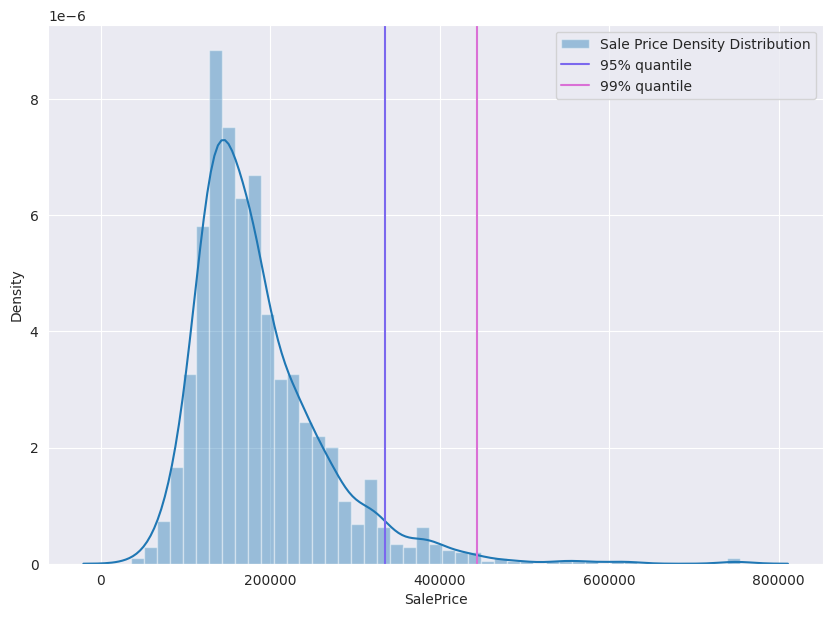

In [ ]:
plt.subplots(figsize=(10,7))
sns.distplot(data['SalePrice'], label='Sale Price Density Distribution')
plt.axvline(data.SalePrice.quantile(0.95), label='95% quantile', c='mediumslateblue')
plt.axvline(data.SalePrice.quantile(0.99), label='99% quantile', c='orchid')
plt.legend()
plt.show()

На графике выше мы видим длинный тонкий хвост справа, в этом хвосте лежат "выбросы", те точки, что лежат за 95 и 99 квантилями. Судя по графику, имеет смысл дропнуть выбросы. Давайте так и поступим:

In [ ]:
data.SalePrice.quantile(0.99)

np.float64(443944.42999999924)

In [ ]:
data=data.loc[data.SalePrice<data.SalePrice.quantile(0.99)]
data.shape

(1324, 74)

Теперь давайте посмотрим на распределение цены на дома в зависимости от зон:

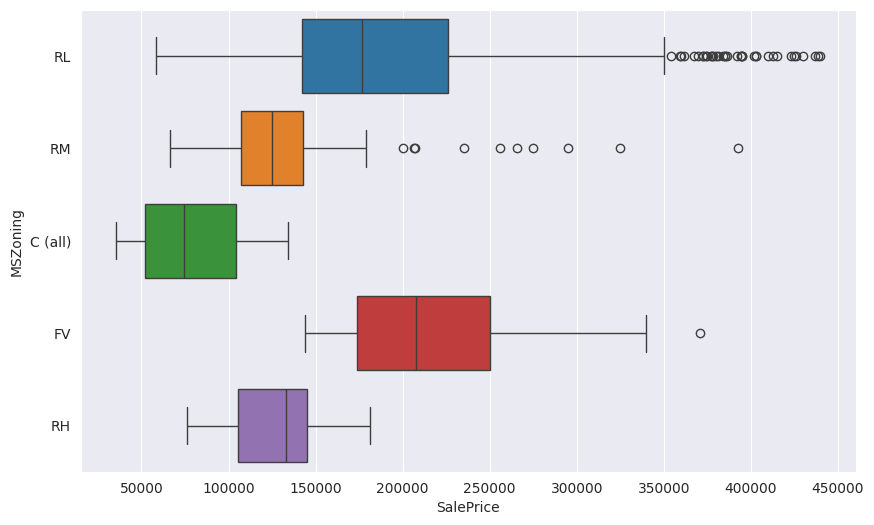

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='SalePrice', y='MSZoning', hue='MSZoning')
plt.show()

График распределения SalePrice по Overall Quality

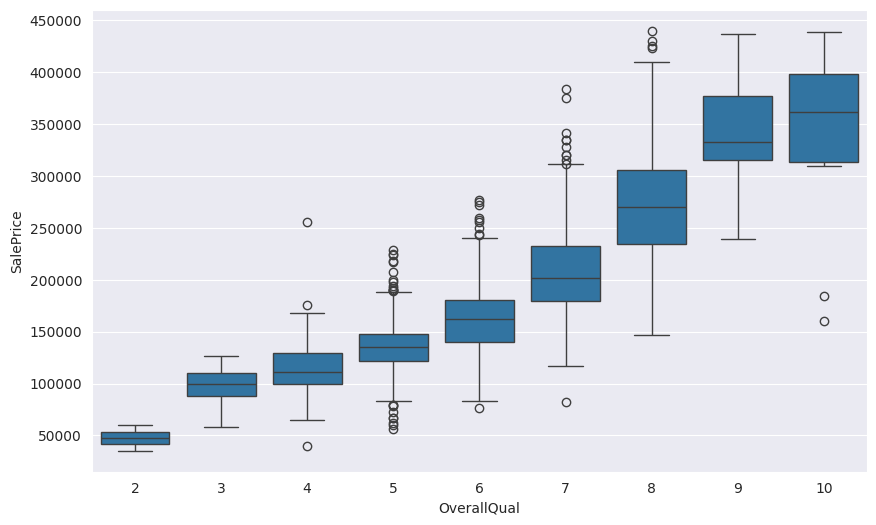

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='OverallQual', y="SalePrice")
plt.show()

# Распределение целевой переменной


Мы уже отмечали выше, что распределение целевой переменной похоже на нормальное. Но так ли это? Давайте попробуем зафитить на наши данные нормальное распределение и нарисуем теоретическое найденное распределение вместе с нашим реальным:

Text(0.5, 1.0, 'SalePrice Density Distribution')

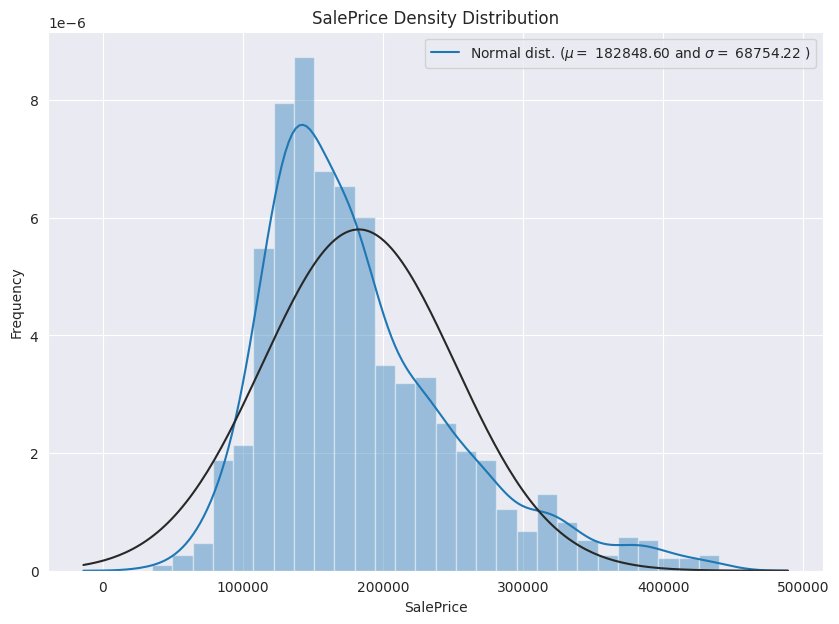

In [ ]:
from scipy import stats
from scipy.stats import norm

plt.figure(figsize=(10,7))
sns.distplot(data.SalePrice, fit=norm)

# фитим распределение
(mu, sigma) = norm.fit(data.SalePrice)

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice Density Distribution')



Как видим на графике выше, наше распределение не совсем нормальное, т.е. оно скошено и имеет большую плотность в районе среднего, чем обычное нормальное. Давайте сделаем монотонное преобразование целевой переменной и посмотрим, станет ли лучше:

Text(0.5, 1.0, 'Log of SalePrice Density Distribution')

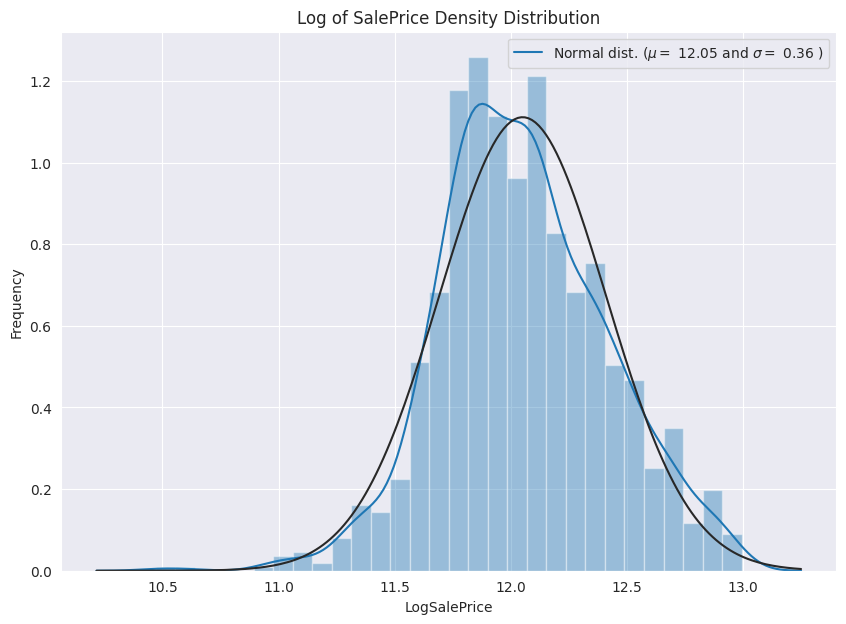

In [ ]:
# берем логарифм от цены
data['LogSalePrice'] = np.log1p(data.SalePrice)

plt.figure(figsize=(10,7))
sns.distplot(data.LogSalePrice, fit=norm)

# фитим распределение на логарифм от цены
(mu, sigma) = norm.fit(data.LogSalePrice)

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.ylabel('Frequency')
plt.title('Log of SalePrice Density Distribution')



Text(0.5, 1.0, 'Log of SalePrice Density Distribution')

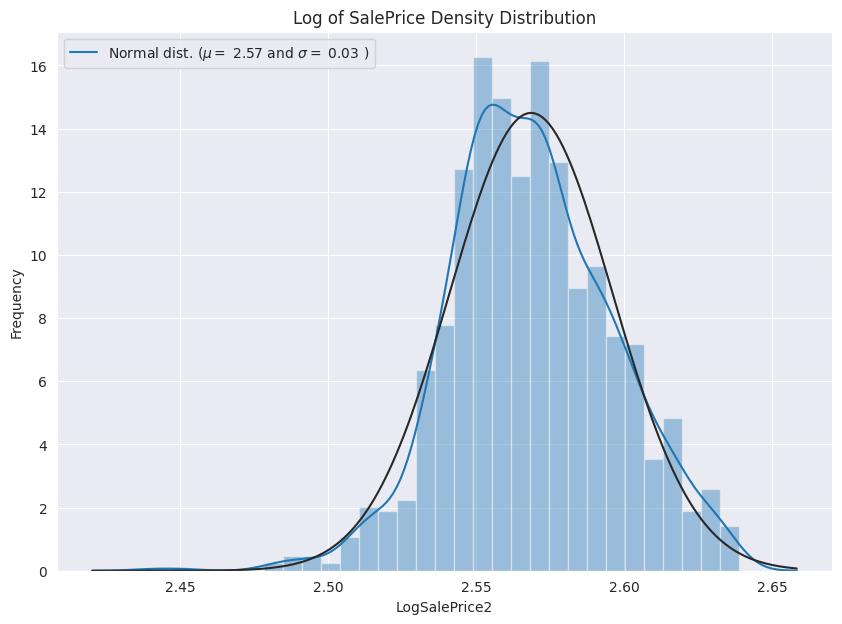

In [ ]:
# берем логарифм от цены
data['LogSalePrice2'] = np.log1p(data.LogSalePrice)

plt.figure(figsize=(10,7))
sns.distplot(data.LogSalePrice2, fit=norm)

# фитим распределение на логарифм от цены
(mu, sigma) = norm.fit(data.LogSalePrice2)

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.ylabel('Frequency')
plt.title('Log of SalePrice Density Distribution')



In [ ]:
data.drop('SalePrice', axis = 1, inplace = True)

In [ ]:
data.drop('LoSalePrice', axis = 1, inplace = True)

Гораздо лучше :)

### Стало интересно? Тогда ждем тебя на [специализации ML](https://otus.ru/lessons/ml-specialization/)!

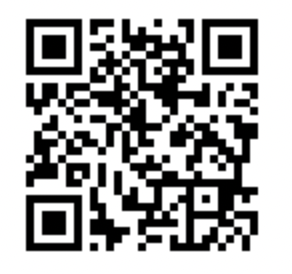